<a href="https://colab.research.google.com/github/EduardoKenzoHayashi/CN-Lobosco/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

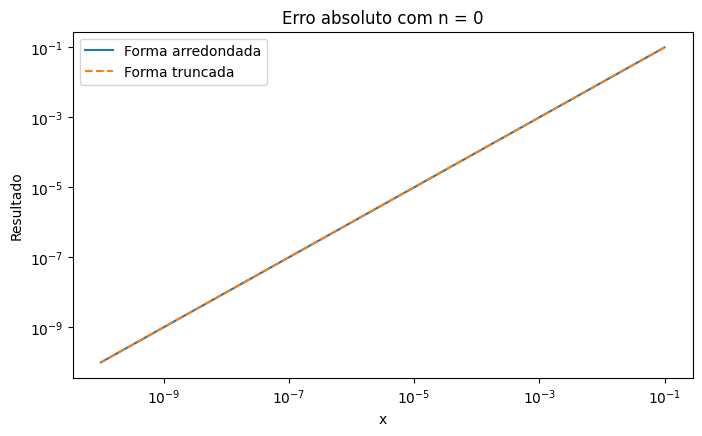

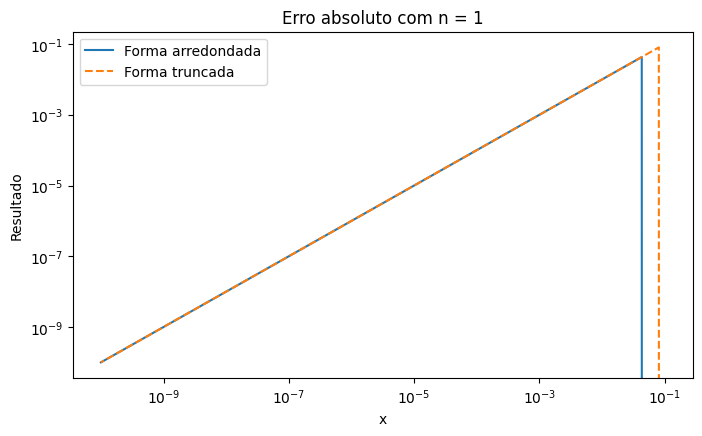

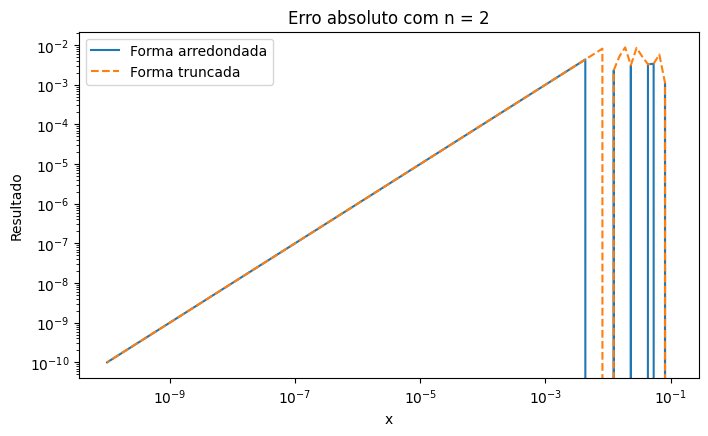

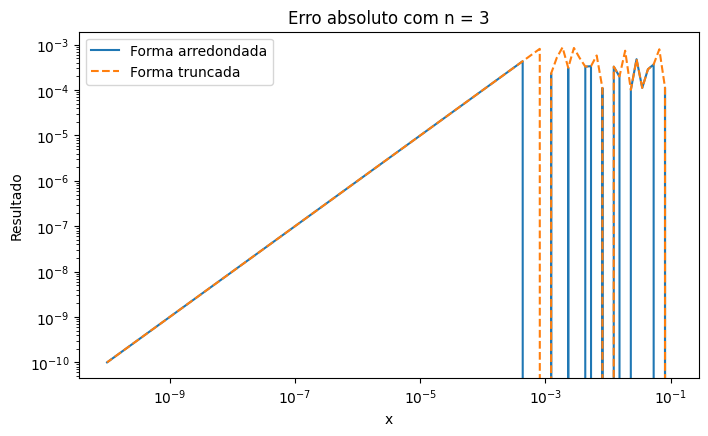

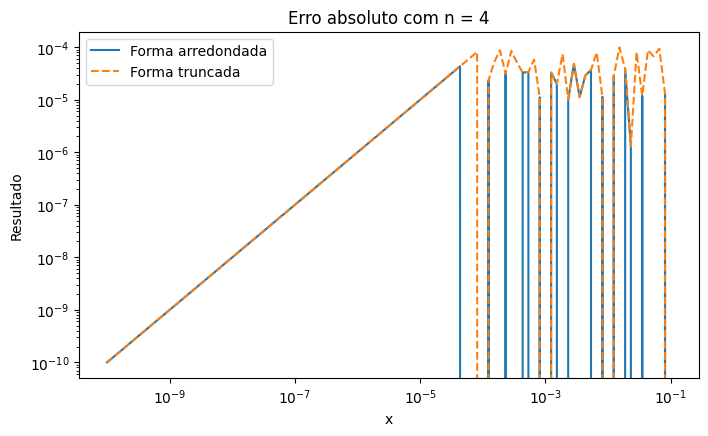

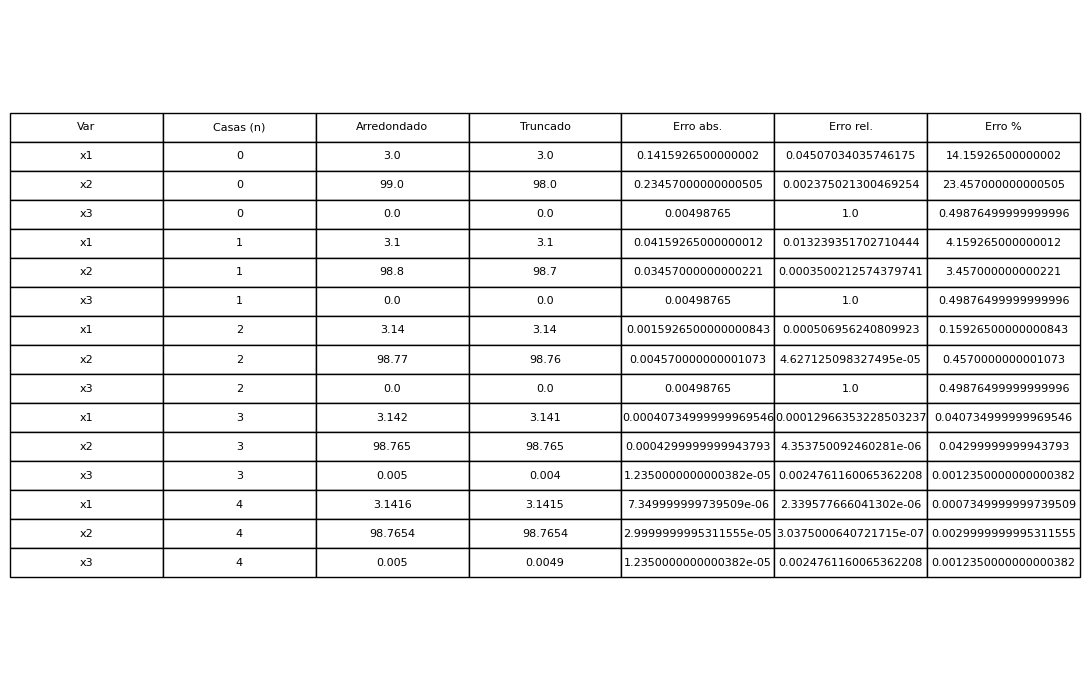

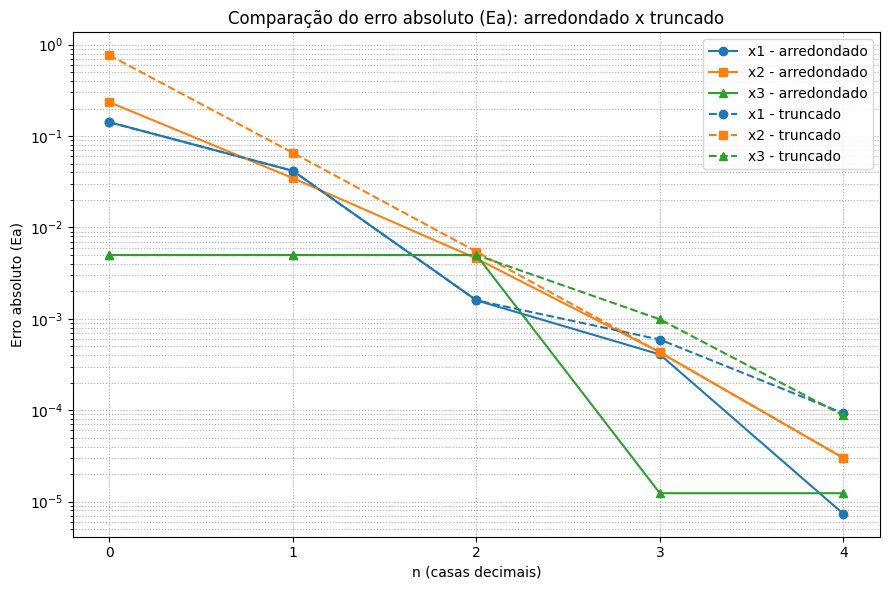

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

def err_abs(x,n):
  return abs(x-round(x,n))

def err_rel(err,x):
  return err/abs(x)

def err_per(err):
  return err*100

x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
linhas = []
for n in range(0,5):
  linhas.append(["x1", n, round(x1,n), truncar(x1,n), err_abs(x1,n), err_rel(err_abs(x1,n), x1), err_per(err_abs(x1,n))])
  linhas.append(["x2", n, round(x2,n), truncar(x2,n), err_abs(x2,n), err_rel(err_abs(x2,n), x2), err_per(err_abs(x2,n))])
  linhas.append(["x3", n, round(x3,n), truncar(x3,n), err_abs(x3,n), err_rel(err_abs(x3,n), x3), err_per(err_abs(x3,n))])

  # Cria valores de x entre 10⁻¹ e 10⁻¹⁰.
  valores_x = np.logspace(-1, -10, 100)

  # Calcula a forma direta usando NumPy.
  resultados_arr = (valores_x - np.round(valores_x,n))
  resultados_trunc = (valores_x - np.trunc(valores_x * (10**n)) / (10 ** n))

  # Constrói o gráfico em escala logarítmica.
  plt.figure(figsize=(8, 4.5))
  plt.loglog(valores_x, resultados_arr, label="Forma arredondada")

  plt.loglog(valores_x, resultados_trunc, "--", label="Forma truncada")
  plt.xlabel("x")
  plt.ylabel("Resultado")
  plt.legend()

  plt.title(f"Erro absoluto com n = {n}")
  plt.show()


colunas = [
    "Var", "Casas (n)", "Arredondado",
    "Truncado", "Erro abs.", "Erro rel.", "Erro %"
]

fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off')

tabela = ax.table(cellText=linhas, colLabels=colunas, loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.scale(1, 1.4)
plt.tight_layout()
plt.show()
# --- Gráfico de Ea em função de n (escala log no eixo y) ---

# Função auxiliar para calcular o erro absoluto do valor TRUNCADO.
# Repara que é igual à ideia do err_abs, mas comparando x com truncar(x, n)
# em vez de comparar x com round(x, n).
def err_abs_trunc(x, n):
    return abs(x - truncar(x, n))

# Lista com os valores de n usados na tabela (0, 1, 2, 3, 4).
ns = list(range(0, 5))

# --- Erros absolutos usando ARREDONDAMENTO (round) ---
# Para cada n, calcula o Ea de x1 comparando x1 com round(x1, n).
ea_x1_round = [err_abs(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_round = [err_abs(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_round = [err_abs(x3, n) for n in ns]

# --- Erros absolutos usando TRUNCAMENTO (truncar) ---
# Para cada n, calcula o Ea de x1 comparando x1 com truncar(x1, n).
ea_x1_trunc = [err_abs_trunc(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_trunc = [err_abs_trunc(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_trunc = [err_abs_trunc(x3, n) for n in ns]

# Cria uma nova figura (janela do gráfico) com tamanho 9x6 polegadas.
plt.figure(figsize=(9, 6))

# --- Curvas do arredondamento (linha cheia) ---
# Plota Ea de x1 (arredondado) em função de n, com escala log no eixo Y.
#sesmiology é usado quando os dados têm uma diferença muito grande de escala entre os valores, e um gráfico linear normal esconderia essa diferença.
plt.semilogy(ns, ea_x1_round, marker='o', linestyle='-', color='tab:blue', label='x1 - arredondado')
# Plota Ea de x2 (arredondado) em função de n.
plt.semilogy(ns, ea_x2_round, marker='s', linestyle='-', color='tab:orange', label='x2 - arredondado')
# Plota Ea de x3 (arredondado) em função de n.
plt.semilogy(ns, ea_x3_round, marker='^', linestyle='-', color='tab:green', label='x3 - arredondado')

# --- Curvas do truncamento (linha tracejada, mesma cor da variável correspondente) ---
# Plota Ea de x1 (truncado) em função de n. Usa a mesma cor de x1 arredondado,
# mas com linha tracejada ('--'), para ficar fácil comparar visualmente o par.
plt.semilogy(ns, ea_x1_trunc, marker='o', linestyle='--', color='tab:blue', label='x1 - truncado')
# Plota Ea de x2 (truncado) em função de n.
plt.semilogy(ns, ea_x2_trunc, marker='s', linestyle='--', color='tab:orange', label='x2 - truncado')
# Plota Ea de x3 (truncado) em função de n.
plt.semilogy(ns, ea_x3_trunc, marker='^', linestyle='--', color='tab:green', label='x3 - truncado')

# Define o rótulo do eixo X.
plt.xlabel("n (casas decimais)")

# Define o rótulo do eixo Y.
plt.ylabel("Erro absoluto (Ea)")

# Define o título do gráfico, deixando claro que é uma comparação.
plt.title("Comparação do erro absoluto (Ea): arredondado x truncado")

# Garante que o eixo X mostre exatamente os valores inteiros de n (0,1,2,3,4).
plt.xticks(ns)

# Mostra a legenda com todas as 6 curvas (3 arredondadas + 3 truncadas).
plt.legend()

# Adiciona grade pontilhada nas linhas principais e secundárias
# (facilita muito a leitura em escala logarítmica).
plt.grid(True, which="both", ls=":")

# Ajusta os espaçamentos automaticamente para nada ficar cortado.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()

Olhando os gráficos, arrendodar gera um erro menor ou igual ao erro absoluto gerado por valores truncados

In [8]:
def erroa(refer, aprox):
  return abs(refer - aprox)

In [9]:
r = 0.8*(10 ** (-3))
L = 0.2
mi = 3.5 * (10 ** (-3))
p = 1200
Q = (math.pi*(r**4)*p)/(8*mi*L)
print(Q)

2.757420751950813e-07


In [11]:
rtrunc = truncar(0.8,1)
rarr = round(0.8,1)
Qtrunc = (math.pi*((rtrunc*(10**-3))**4)*p)/(8*mi*L)
Qarr = (math.pi*((rarr*(10**-3))**4)*p)/(8*mi*L)
print(f"Q com r truncado {Qtrunc}")
print(f"Q com r arredondado {Qarr}")
print(f"O erro absoluto do Q com r truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com r proximado seria {erroa(Q, Qarr)}")


Q com r truncado 2.757420751950813e-07
Q com r arredondado 2.757420751950813e-07
O erro absoluto do Q com r truncado seria 0.0
O erro absoluto do Q com r proximado seria 0.0


In [12]:
mitrunc = truncar(mi , 3)
miarr = round(mi,3)

Qtrunc = (math.pi*(r**4)*p)/(8*mitrunc*L)
Qarr = (math.pi*(r**4)*p)/(8*miarr*L)
print(f"Q com mi truncado {Qtrunc}")
print(f"Q com mi arredondado {Qarr}")

print(f"O erro absoluto do Q com mi truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com mi proximado seria {erroa(Q, Qarr)}")


Q com r truncado 3.2169908772759484e-07
Q com r arredondado 2.4127431579569616e-07
O erro absoluto do Q com r truncado seria 4.5957012532513556e-08
O erro absoluto do Q com r proximado seria 3.446775939938513e-08


In [13]:
ptrunc = 12
parr = 12
Qarr = (math.pi*(r**4)*parr)/(8*mi*L)
Qtrunc = (math.pi*(r**4)*ptrunc)/(8*mi*L)
print(f"Q com delta p truncado {Qtrunc}")
print(f"Q com delta p arredondado {Qarr}")

print(f"O erro absoluto do Q com delta p truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com delta p proximado seria {erroa(Q, Qarr)}")


Q com r truncado 2.7574207519508133e-09
Q com r arredondado 2.7574207519508133e-09
O erro absoluto do Q com r truncado seria 2.7298465444313047e-07
O erro absoluto do Q com r proximado seria 2.7298465444313047e-07


In [14]:
Qarr = (math.pi*((rarr*(10**-3))**4)*parr)/(8*miarr*L)
Qtrunc = (math.pi*((rtrunc*(10**-3))**4)*ptrunc)/(8*mitrunc*L)
print(f"Q com tudo truncado {Qtrunc}")
print(f"Q com tudo arredondado {Qarr}")

print(f"O erro absoluto do Q com tudo truncado seria {erroa(Q, Qtrunc)}")
print(f"O erro absoluto do Q com tudo proximado seria {erroa(Q, Qarr)}")

Q com tudo truncado 3.216990877275949e-09
Q com tudo arredondado 2.4127431579569616e-09
O erro absoluto do Q com r truncado seria 2.7252508431780536e-07
O erro absoluto do Q com r proximado seria 2.7332933203712433e-07


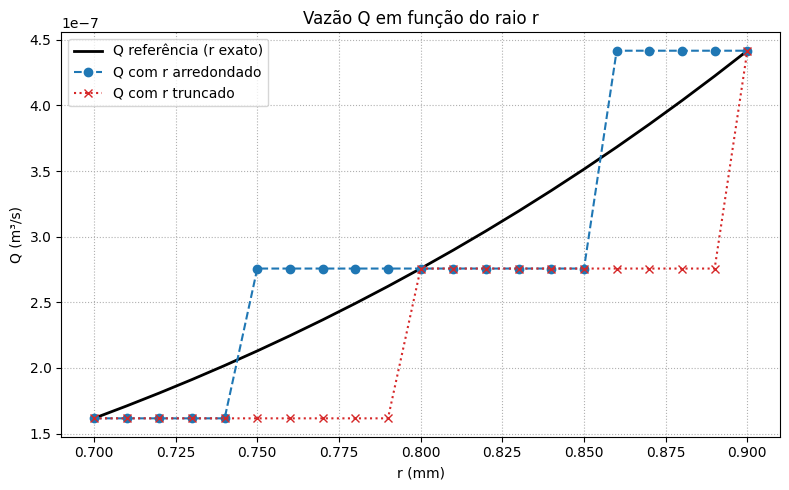

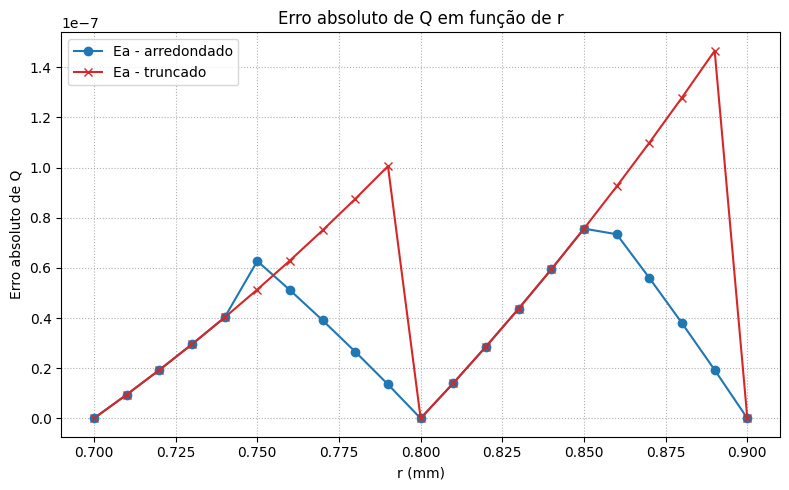

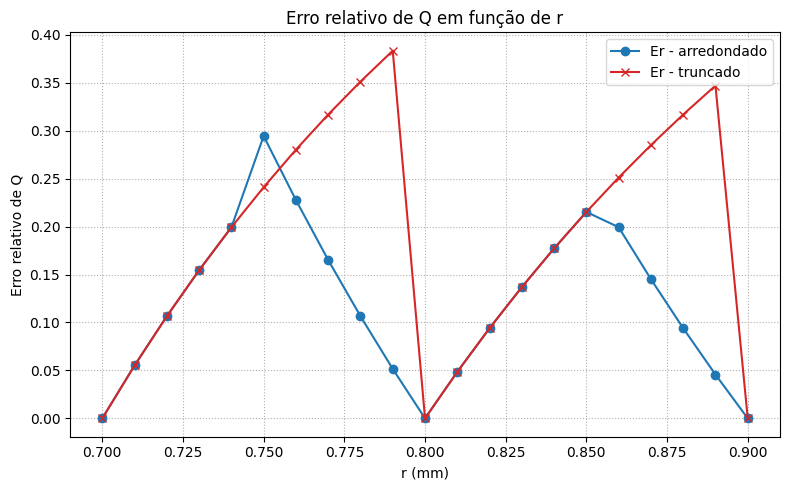

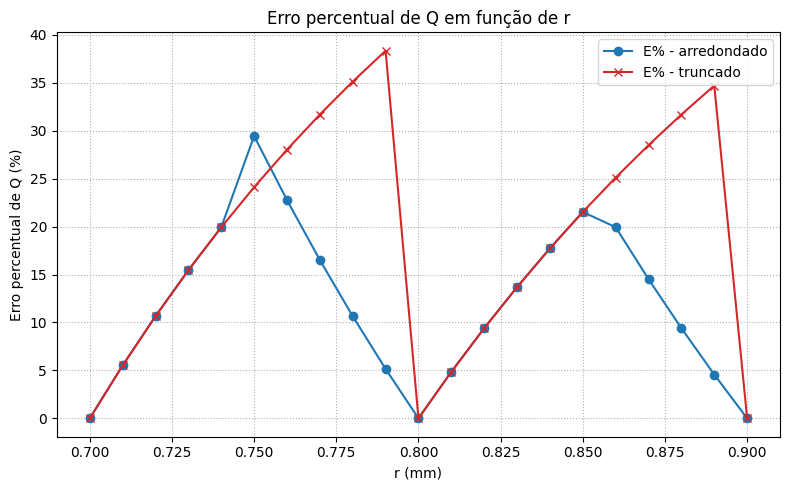

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Função de truncamento (já usada nos itens anteriores)
# ---------------------------------------------------------
def truncar(numero, casas):
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

# ---------------------------------------------------------
# Função que calcula a vazão Q pela Lei de Hagen–Poiseuille
# Q = (pi * r^4 * dp) / (8 * mu * L)
# IMPORTANTE: r deve estar em METROS aqui dentro.
# ---------------------------------------------------------
def calc_Q(r_m, dp, mu, L):
    return (math.pi * r_m**4 * dp) / (8 * mu * L)

# ---------------------------------------------------------
# Parâmetros fixos do problema
# ---------------------------------------------------------
L = 0.20          # comprimento do tubo, em metros
mu = 3.5e-3       # viscosidade dinâmica, em Pa.s
dp = 1200         # diferença de pressão, em Pa

# ---------------------------------------------------------
# Faixa de raios a variar: de 0,70 mm a 0,90 mm, passo 0,01 mm
# ---------------------------------------------------------
r_mm = np.arange(0.70, 0.90 + 1e-9, 0.01)  # raios em milímetros

# Listas para guardar os resultados de cada raio
lista_r          = []
lista_Q_ref      = []
lista_Q_round    = []
lista_Q_trunc    = []
lista_Ea_round   = []
lista_Ea_trunc   = []
lista_Er_round   = []
lista_Er_trunc   = []
lista_Ep_round   = []
lista_Ep_trunc   = []

# ---------------------------------------------------------
# Loop principal: para cada raio da faixa, calcula:
# - Q de referência (raio exato, sem arredondar/truncar)
# - Q com raio arredondado para 1 casa decimal (em mm)
# - Q com raio truncado para 1 casa decimal (em mm)
# - os erros absoluto, relativo e percentual de cada aproximação
# ---------------------------------------------------------
for r in r_mm:
    # --- Raio de referência (exato) convertido para metros ---
    r_ref_m = r / 1000.0

    # --- Raio arredondado para 1 casa decimal (ainda em mm), depois convertido para metros ---
    r_round_mm = round(r, 1)
    r_round_m = r_round_mm / 1000.0

    # --- Raio truncado para 1 casa decimal (ainda em mm), depois convertido para metros ---
    r_trunc_mm = truncar(r, 1)
    r_trunc_m = r_trunc_mm / 1000.0

    # --- Calcula Q para os três casos usando a função de Poiseuille ---
    Q_ref   = calc_Q(r_ref_m,   dp, mu, L)
    Q_round = calc_Q(r_round_m, dp, mu, L)
    Q_trunc = calc_Q(r_trunc_m, dp, mu, L)

    # --- Erro absoluto: |Q_referencia - Q_aproximado| ---
    Ea_round = abs(Q_ref - Q_round)
    Ea_trunc = abs(Q_ref - Q_trunc)

    # --- Erro relativo: Ea dividido pelo valor de referência ---
    Er_round = Ea_round / abs(Q_ref)
    Er_trunc = Ea_trunc / abs(Q_ref)

    # --- Erro percentual: erro relativo multiplicado por 100 ---
    Ep_round = Er_round * 100
    Ep_trunc = Er_trunc * 100

    # --- Guarda tudo nas listas para usar depois nos gráficos ---
    lista_r.append(r)
    lista_Q_ref.append(Q_ref)
    lista_Q_round.append(Q_round)
    lista_Q_trunc.append(Q_trunc)
    lista_Ea_round.append(Ea_round)
    lista_Ea_trunc.append(Ea_trunc)
    lista_Er_round.append(Er_round)
    lista_Er_trunc.append(Er_trunc)
    lista_Ep_round.append(Ep_round)
    lista_Ep_trunc.append(Ep_trunc)

# ===========================================================
# GRÁFICO 1: Q em função de r (referência, arredondado, truncado)
# ===========================================================

# Cria uma nova figura (janela do gráfico) com tamanho 8x5 polegadas.
plt.figure(figsize=(8, 5))

# Plota a curva de Q "de referência", ou seja, calculado com o raio exato,
# sem nenhum arredondamento ou truncamento.
# - color="black" e linewidth=2 destacam essa curva como a "correta"/base de comparação.
plt.plot(lista_r, lista_Q_ref,
          label="Q referência (r exato)",
          color="black",
          linewidth=2)

# Plota a curva de Q calculado com o raio ARREDONDADO para 1 casa decimal.
# - linestyle="--" (tracejado) e marker="o" (bolinha) ajudam a diferenciar
#   visualmente essa curva da curva de referência.
plt.plot(lista_r, lista_Q_round,
          label="Q com r arredondado",
          color="tab:blue",
          linestyle="--",
          marker="o")

# Plota a curva de Q calculado com o raio TRUNCADO para 1 casa decimal.
# - linestyle=":" (pontilhado) e marker="x" deixam essa curva visualmente
#   diferente das outras duas.
plt.plot(lista_r, lista_Q_trunc,
          label="Q com r truncado",
          color="tab:red",
          linestyle=":",
          marker="x")

# Define o rótulo do eixo X (o raio, em milímetros).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (a vazão Q, em metros cúbicos por segundo).
plt.ylabel("Q (m³/s)")

# Define o título do gráfico.
plt.title("Vazão Q em função do raio r")

# Mostra a legenda com os nomes definidos em cada "label" acima.
plt.legend()

# Adiciona uma grade pontilhada para facilitar a leitura dos valores nos eixos.
plt.grid(True, ls=":")

# Ajusta automaticamente os espaçamentos da figura para nada ficar cortado.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()


# ===========================================================
# GRÁFICO 2: Erro absoluto de Q em função de r
# ===========================================================

# Cria uma nova figura para o gráfico de erro absoluto.
plt.figure(figsize=(8, 5))

# Plota o erro absoluto (Ea) de Q quando o raio foi ARREDONDADO,
# em função do raio original (não arredondado) usado em cada ponto.
plt.plot(lista_r, lista_Ea_round,
          label="Ea - arredondado",
          color="tab:blue",
          marker="o")

# Plota o erro absoluto (Ea) de Q quando o raio foi TRUNCADO,
# em função do raio original usado em cada ponto.
plt.plot(lista_r, lista_Ea_trunc,
          label="Ea - truncado",
          color="tab:red",
          marker="x")

# Define o rótulo do eixo X (raio em mm).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (erro absoluto de Q, mesma unidade de Q: m³/s).
plt.ylabel("Erro absoluto de Q")

# Define o título do gráfico.
plt.title("Erro absoluto de Q em função de r")

# Mostra a legenda distinguindo arredondado x truncado.
plt.legend()

# Adiciona grade pontilhada para facilitar a leitura.
plt.grid(True, ls=":")

# Ajusta os espaçamentos automaticamente.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()


# ===========================================================
# GRÁFICO 3: Erro relativo de Q em função de r
# ===========================================================

# Cria uma nova figura para o gráfico de erro relativo.
plt.figure(figsize=(8, 5))

# Plota o erro relativo (Er = Ea / Q_referência) para o caso ARREDONDADO.
# O erro relativo é adimensional (não tem unidade), pois é uma razão entre
# duas grandezas de mesma unidade (Ea e Q).
plt.plot(lista_r, lista_Er_round,
          label="Er - arredondado",
          color="tab:blue",
          marker="o")

# Plota o erro relativo (Er) para o caso TRUNCADO.
plt.plot(lista_r, lista_Er_trunc,
          label="Er - truncado",
          color="tab:red",
          marker="x")

# Define o rótulo do eixo X (raio em mm).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (erro relativo, sem unidade).
plt.ylabel("Erro relativo de Q")

# Define o título do gráfico.
plt.title("Erro relativo de Q em função de r")

# Mostra a legenda distinguindo arredondado x truncado.
plt.legend()

# Adiciona grade pontilhada para facilitar a leitura.
plt.grid(True, ls=":")

# Ajusta os espaçamentos automaticamente.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()


# ===========================================================
# GRÁFICO 4: Erro percentual de Q em função de r
# ===========================================================

# Cria uma nova figura para o gráfico de erro percentual.
plt.figure(figsize=(8, 5))

# Plota o erro percentual (E% = Er * 100) para o caso ARREDONDADO.
# É basicamente o mesmo gráfico do erro relativo, só que em escala de 0 a 100(%).
plt.plot(lista_r, lista_Ep_round,
          label="E% - arredondado",
          color="tab:blue",
          marker="o")

# Plota o erro percentual (E%) para o caso TRUNCADO.
plt.plot(lista_r, lista_Ep_trunc,
          label="E% - truncado",
          color="tab:red",
          marker="x")

# Define o rótulo do eixo X (raio em mm).
plt.xlabel("r (mm)")

# Define o rótulo do eixo Y (erro percentual de Q, em %).
plt.ylabel("Erro percentual de Q (%)")

# Define o título do gráfico.
plt.title("Erro percentual de Q em função de r")

# Mostra a legenda distinguindo arredondado x truncado.
plt.legend()

# Adiciona grade pontilhada para facilitar a leitura.
plt.grid(True, ls=":")

# Ajusta os espaçamentos automaticamente.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()

In [ ]:
"""
Parte E - Síntese visual
========================
Gera um único PNG (>=1600x1000 px) reunindo:
  - cartões com os principais valores de pressão e vazão (tubo e nanocateter);
  - comparação entre truncamento e arredondamento (Ea de Q para r, mu, dp);
  - os três tipos de erro (Ea, Er, E%) no cenário "todas as aproximações juntas";
  - sensibilidade de Q ao raio (0,70 a 0,90 mm);
  - comparação float32 x float64 (nanocateter);
  - uma conclusão curta sobre o nanocateter.
"""

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===========================================================
# FUNÇÕES BÁSICAS (as mesmas usadas nas partes anteriores)
# ===========================================================

def truncar(numero, casas):
    """Trunca 'numero' para 'casas' decimais, sem arredondar."""
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

def calc_Q(r_m, dp, mu, L):
    """Lei de Hagen-Poiseuille: Q = pi * r^4 * dp / (8 * mu * L). r em metros."""
    return (math.pi * r_m**4 * dp) / (8 * mu * L)

def erro_abs(x, x_aprox):
    return abs(x - x_aprox)

def erro_rel(ea, x):
    return ea / abs(x)

def erro_pct(er):
    return er * 100


# ===========================================================
# BLOCO 1 - PARÂMETROS BASE (Parte C: tubo) e (Parte D: nanocateter)
# ===========================================================

# --- Tubo (Parte C) ---
r_tubo_mm = 0.80          # raio em mm
L_tubo = 0.20             # comprimento, em m
mu_tubo = 3.5e-3          # viscosidade, em Pa.s
dp_tubo = 1200            # diferença de pressão, em Pa

Q_ref_tubo = calc_Q(r_tubo_mm / 1000, dp_tubo, mu_tubo, L_tubo)

# --- Nanocateter (Parte D) ---
r_nano_m = 50e-9          # 50 nm em metros
L_nano_m = 10e-6          # 10 micrometros em metros
mu_nano = 3.5e-3          # Pa.s
dp_nano = 5000            # Pa

Q_ref_nano = calc_Q(r_nano_m, dp_nano, mu_nano, L_nano_m)


# ===========================================================
# BLOCO 2 - COMPARAÇÃO TRUNCAMENTO x ARREDONDAMENTO (Parte C.1)
# Aproxima r (1 casa decimal em mm), mu (3 casas decimais em Pa.s)
# e dp (centena de Pa) - isoladamente e "todas juntas" - e mede o
# impacto (Ea) sobre Q.
# ===========================================================

# --- r isolado ---
r_round_mm = round(r_tubo_mm, 1)
r_trunc_mm = truncar(r_tubo_mm, 1)
Q_r_round = calc_Q(r_round_mm / 1000, dp_tubo, mu_tubo, L_tubo)
Q_r_trunc = calc_Q(r_trunc_mm / 1000, dp_tubo, mu_tubo, L_tubo)

# --- mu isolado ---
mu_round = round(mu_tubo, 3)
mu_trunc = truncar(mu_tubo, 3)
Q_mu_round = calc_Q(r_tubo_mm / 1000, dp_tubo, mu_round, L_tubo)
Q_mu_trunc = calc_Q(r_tubo_mm / 1000, dp_tubo, mu_trunc, L_tubo)

# --- dp isolado (arredondar/truncar para centena) ---
dp_round = round(dp_tubo, -2)
dp_trunc = math.trunc(dp_tubo / 100) * 100
Q_dp_round = calc_Q(r_tubo_mm / 1000, dp_round, mu_tubo, L_tubo)
Q_dp_trunc = calc_Q(r_tubo_mm / 1000, dp_trunc, mu_tubo, L_tubo)

# --- todas as aproximações simultaneamente ---
Q_all_round = calc_Q(r_round_mm / 1000, dp_round, mu_round, L_tubo)
Q_all_trunc = calc_Q(r_trunc_mm / 1000, dp_trunc, mu_trunc, L_tubo)

# Erros absolutos (Ea) de Q para cada cenário, comparando com Q_ref_tubo
Ea_round_por_variavel = [
    erro_abs(Q_ref_tubo, Q_r_round),
    erro_abs(Q_ref_tubo, Q_mu_round),
    erro_abs(Q_ref_tubo, Q_dp_round),
    erro_abs(Q_ref_tubo, Q_all_round),
]
Ea_trunc_por_variavel = [
    erro_abs(Q_ref_tubo, Q_r_trunc),
    erro_abs(Q_ref_tubo, Q_mu_trunc),
    erro_abs(Q_ref_tubo, Q_dp_trunc),
    erro_abs(Q_ref_tubo, Q_all_trunc),
]
rotulos_variaveis = ["r isolado", "μ isolado", "Δp isolado", "todas juntas"]


# ===========================================================
# BLOCO 3 - OS TRÊS TIPOS DE ERRO (Ea, Er, E%) no cenário
# "todas as aproximações simultaneamente" (arredondado x truncado)
# ===========================================================

Ea_all_round = erro_abs(Q_ref_tubo, Q_all_round)
Er_all_round = erro_rel(Ea_all_round, Q_ref_tubo)
Ep_all_round = erro_pct(Er_all_round)

Ea_all_trunc = erro_abs(Q_ref_tubo, Q_all_trunc)
Er_all_trunc = erro_rel(Ea_all_trunc, Q_ref_tubo)
Ep_all_trunc = erro_pct(Er_all_trunc)


# ===========================================================
# BLOCO 4 - SENSIBILIDADE DE Q AO RAIO (Parte C.2): 0,70 a 0,90 mm
# ===========================================================

r_mm_faixa = np.arange(0.70, 0.90 + 1e-9, 0.01)

Q_ref_faixa, Q_round_faixa, Q_trunc_faixa = [], [], []
for r in r_mm_faixa:
    Q_ref_faixa.append(calc_Q(r / 1000, dp_tubo, mu_tubo, L_tubo))
    Q_round_faixa.append(calc_Q(round(r, 1) / 1000, dp_tubo, mu_tubo, L_tubo))
    Q_trunc_faixa.append(calc_Q(truncar(r, 1) / 1000, dp_tubo, mu_tubo, L_tubo))


# ===========================================================
# BLOCO 5 - COMPARAÇÃO float32 x float64 (Parte D.2, nanocateter)
# ===========================================================

r32 = np.float32(r_nano_m)
r64 = np.float64(r_nano_m)
dp32 = np.float32(dp_nano)
dp64 = np.float64(dp_nano)
mu32 = np.float32(mu_nano)
mu64 = np.float64(mu_nano)
L32 = np.float32(L_nano_m)
L64 = np.float64(L_nano_m)

r4_32 = r32 ** 4
r4_64 = r64 ** 4

Q_32 = (np.pi * r32**4 * dp32) / (8 * mu32 * L32)
Q_64 = (np.pi * r64**4 * dp64) / (8 * mu64 * L64)

diff_abs_floats = abs(float(Q_64) - float(Q_32))
diff_rel_floats = diff_abs_floats / abs(float(Q_64))

eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps


# ===========================================================
# BLOCO 6 - MONTAGEM DO QUADRO ÚNICO (FIGURA)
# figsize=(16,10) com dpi=150 -> 2400x1500 px (acima do mínimo de 1600x1000)
# ===========================================================

fig = plt.figure(figsize=(16, 10), dpi=150)
fig.suptitle(
    "Cálculo Numérico — Atividade Prática I\nQuadro-síntese: erros, vazão e precisão numérica",
    fontsize=16, fontweight="bold"
)

# Grade principal: 3 linhas x 4 colunas.
# Linha 0 -> cartões de valores principais
# Linha 1 -> os três gráficos analíticos
# Linha 2 -> tabela float32/64 + conclusão
gs = gridspec.GridSpec(
    3, 4, figure=fig,
    height_ratios=[0.8, 1.6, 1.1],
    hspace=0.55, wspace=0.45,
    top=0.88, bottom=0.05, left=0.05, right=0.97
)

# -----------------------------------------------------------
# LINHA 0: 4 "cartões" com os principais valores de pressão/vazão
# -----------------------------------------------------------
cartoes_info = [
    ("Tubo — parâmetros",
     f"r = {r_tubo_mm:.2f} mm\nL = {L_tubo:.2f} m\nμ = {mu_tubo:.1e} Pa·s\nΔp = {dp_tubo} Pa",
     "#e8f0fe"),
    ("Tubo — vazão de referência",
     f"Q_ref = {Q_ref_tubo:.4e} m³/s",
     "#e6f4ea"),
    ("Nanocateter — parâmetros",
     f"r = 50 nm\nL = 10 μm\nμ = {mu_nano:.1e} Pa·s\nΔp = {dp_nano} Pa",
     "#fef7e0"),
    ("Nanocateter — vazão de referência",
     f"Q_ref = {Q_ref_nano:.4e} m³/s",
     "#fce8e6"),
]

for i, (titulo, texto, cor) in enumerate(cartoes_info):
    ax_card = fig.add_subplot(gs[0, i])
    ax_card.axis("off")
    # Desenha um "cartão" colorido de fundo.
    ax_card.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax_card.transAxes,
                                     facecolor=cor, edgecolor="gray", linewidth=1))
    ax_card.text(0.5, 0.78, titulo, ha="center", va="center",
                 fontsize=10, fontweight="bold", transform=ax_card.transAxes)
    ax_card.text(0.5, 0.38, texto, ha="center", va="center",
                 fontsize=9, transform=ax_card.transAxes)

# -----------------------------------------------------------
# LINHA 1, COLUNAS 0-1 (mais larga): sensibilidade de Q ao raio
# -----------------------------------------------------------
ax_sens = fig.add_subplot(gs[1, 0:2])
ax_sens.plot(r_mm_faixa, Q_ref_faixa, color="black", linewidth=2, label="Q referência")
ax_sens.plot(r_mm_faixa, Q_round_faixa, "--o", color="tab:blue", markersize=4, label="Q (r arredondado)")
ax_sens.plot(r_mm_faixa, Q_trunc_faixa, ":x", color="tab:red", markersize=5, label="Q (r truncado)")
ax_sens.set_xlabel("r (mm)")
ax_sens.set_ylabel("Q (m³/s)")
ax_sens.set_title("Sensibilidade de Q ao raio (tubo)")
ax_sens.legend(fontsize=8)
ax_sens.grid(True, ls=":")

# -----------------------------------------------------------
# LINHA 1, COLUNA 2: comparação truncamento x arredondamento (Ea de Q)
# -----------------------------------------------------------
ax_trunc_round = fig.add_subplot(gs[1, 2])
x_pos = np.arange(len(rotulos_variaveis))
largura = 0.35
ax_trunc_round.bar(x_pos - largura/2, Ea_round_por_variavel, largura,
                    label="Arredondado", color="tab:blue")
ax_trunc_round.bar(x_pos + largura/2, Ea_trunc_por_variavel, largura,
                    label="Truncado", color="tab:red")
ax_trunc_round.set_xticks(x_pos)
ax_trunc_round.set_xticklabels(rotulos_variaveis, rotation=20, ha="right", fontsize=8)
ax_trunc_round.set_ylabel("Ea de Q (m³/s)")
ax_trunc_round.set_title("Truncamento x arredondamento\n(erro absoluto em Q)")
ax_trunc_round.legend(fontsize=8)
ax_trunc_round.grid(True, axis="y", ls=":")

# -----------------------------------------------------------
# LINHA 1, COLUNA 3: os três tipos de erro (escala log),
# cenário "todas as aproximações simultaneamente"
# -----------------------------------------------------------
ax_3erros = fig.add_subplot(gs[1, 3])
categorias_erro = ["Ea", "Er", "E%"]
valores_round = [Ea_all_round, Er_all_round, Ep_all_round]
valores_trunc = [Ea_all_trunc, Er_all_trunc, Ep_all_trunc]
x_pos2 = np.arange(len(categorias_erro))
ax_3erros.bar(x_pos2 - largura/2, valores_round, largura, label="Arredondado", color="tab:blue")
ax_3erros.bar(x_pos2 + largura/2, valores_trunc, largura, label="Truncado", color="tab:red")
ax_3erros.set_yscale("log")  # escalas muito diferentes (Ea ~1e-8, E% ~10)
ax_3erros.set_xticks(x_pos2)
ax_3erros.set_xticklabels(categorias_erro)
ax_3erros.set_ylabel("Valor (escala log)")
ax_3erros.set_title("Os três tipos de erro\n(todas aprox. simultâneas)")
ax_3erros.legend(fontsize=8)
ax_3erros.grid(True, axis="y", which="both", ls=":")

# -----------------------------------------------------------
# LINHA 2, COLUNAS 0-1: tabela float32 x float64 (nanocateter)
# -----------------------------------------------------------
ax_tabela = fig.add_subplot(gs[2, 0:2])
ax_tabela.axis("off")
ax_tabela.set_title("Precisão computacional — float32 x float64 (nanocateter)",
                     fontsize=10, fontweight="bold", loc="left")

dados_tabela = [
    ["r⁴", f"{r4_32:.6e}", f"{r4_64:.6e}"],
    ["Q", f"{Q_32:.6e}", f"{Q_64:.6e}"],
    ["Diferença absoluta (Q64−Q32)", f"{diff_abs_floats:.3e}", ""],
    ["Diferença relativa", f"{diff_rel_floats:.3e}", ""],
    ["eps (np.finfo)", f"{eps32:.3e}", f"{eps64:.3e}"],
]
tabela = ax_tabela.table(
    cellText=dados_tabela,
    colLabels=["Grandeza", "float32", "float64"],
    loc="center", cellLoc="center"
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(8.5)
tabela.scale(1, 1.5)

# -----------------------------------------------------------
# LINHA 2, COLUNAS 2-3: conclusão curta sobre o nanocateter
# -----------------------------------------------------------
ax_concl = fig.add_subplot(gs[2, 2:4])
ax_concl.axis("off")
ax_concl.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax_concl.transAxes,
                                  facecolor="#f1f3f4", edgecolor="gray"))
texto_conclusao = (
    "Conclusão — nanocateter:\n\n"
    "Como Q depende de r⁴, reduzir o raio da escala de milímetros (tubo) para "
    "nanômetros (nanocateter) faz qualquer erro geométrico ser fortemente "
    "amplificado na vazão. Nessa escala, a razão superfície/volume aumenta "
    "muito, tornando os efeitos viscosos e de parede dominantes — o que o "
    "modelo de Hagen–Poiseuille (pensado para escoamentos macroscópicos) "
    "não captura bem. Além disso, como Q assume valores extremamente "
    "pequenos (~1e-19 m³/s), a precisão numérica importa: float32 já perde "
    "dígitos significativos frente ao float64, mostrando que precisão "
    "aritmética alta não garante, sozinha, validade física do modelo."
)
ax_concl.text(0.05, 0.95, texto_conclusao, ha="left", va="top",
              fontsize=9, transform=ax_concl.transAxes, wrap=True)

# ===========================================================
# SALVA O QUADRO ÚNICO EM PNG
# ===========================================================
caminho_saida = "/mnt/user-data/outputs/parte_E_quadro_resultados.png"
fig.savefig(caminho_saida, dpi=150)
print("Figura salva em:", caminho_saida)
print("Tamanho em pixels: 16*150 x 10*150 =", 16*150, "x", 10*150)